In [13]:
%matplotlib inline

import os
import random
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import yaml
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import ultralytics
from ultralytics import YOLO
from sklearn.model_selection import train_test_split

Primeira imagem: /home/pvbm.eng23/dataset_topicos/images_train/100018.png


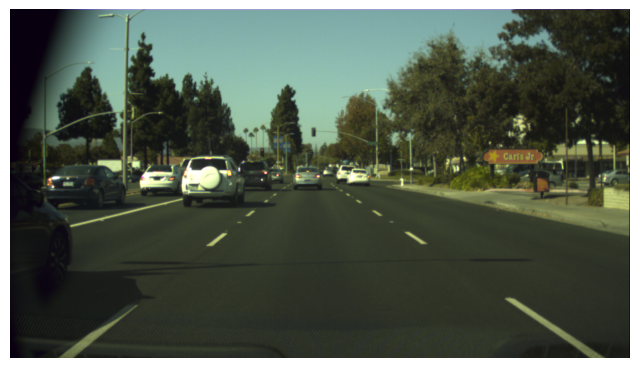

In [50]:
path = Path("/home/pvbm.eng23/dataset_topicos/images_train")

print(f"Primeira imagem: {imagens[0]}")

img = Image.open(imagens[0])

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
a = torch.rand(1000, 4, device="cuda")
b = torch.rand(1000, 4, device="cuda")

for _ in range(1000):
    c = torch.min(a.unsqueeze(1), b.unsqueeze(0))

In [64]:
random.seed(42)

images_path = dataset_path / "images_train"

imgs= list(Path(images_path).glob("*.png"))

saida = dataset_path / "dataset_yolo"

treino = 1000
validacao = 150
teste = 300

random.seed(42)

imgs = random.sample(imgs, 1450)

train_imgs, temp_imgs = train_test_split(
    imgs,
    train_size=1000,
    random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs,
    train_size=150,
    random_state=42
)

print(len(train_imgs))
print(len(val_imgs))
print(len(test_imgs))

1000
150
300


In [62]:
for pasta in ["train", "val", "test"]:
    (dataset_path / "images" / pasta).mkdir(
        parents=True,
        exist_ok=True
    )

    (dataset_path / "labels" / pasta).mkdir(
        parents=True,
        exist_ok=True
    )

In [65]:
for img in train_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/train" / img.name
    )

for img in val_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/val" / img.name
    )

for img in test_imgs:
    shutil.copy2(
        img,
        dataset_path / "images/test" / img.name
    )

In [56]:
train_names = {img.name for img in train_imgs}
val_names = {img.name for img in val_imgs}
test_names = {img.name for img in test_imgs}

In [57]:
CLASS_MAP = {
    "Red": 0,
    "RedLeft": 0,
    "RedRight": 0,

    "Yellow": 1,
    "YellowLeft": 1,
    "YellowRight": 1,

    "Green": 2,
    "GreenLeft": 2,
    "GreenRight": 2
}

In [81]:
for item in data:

    nome = Path(item["path"]).name

    if nome in train_names:
        split = "train"

    elif nome in val_names:
        split = "val"

    elif nome in test_names:
        split = "test"

    else:
        continue

    img_path = (
        dataset_path /
        "images" /
        split /
        nome
    )

    width, height = Image.open(img_path).size

    linhas = []

    for box in item["boxes"]:

        label = box["label"]

        if label not in CLASS_MAP:
            continue

        cls = CLASS_MAP[label]

        xmin = box["x_min"]
        xmax = box["x_max"]
        ymin = box["y_min"]
        ymax = box["y_max"]
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(width, xmax)
        ymax = min(height, ymax)

        if xmax <= xmin or ymax <= ymin:
            continue

        xc = ((xmin + xmax) / 2) / width
        yc = ((ymin + ymax) / 2) / height

        bw = (xmax - xmin) / width
        bh = (ymax - ymin) / height

        linhas.append(
            f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"
        )

    label_file = (
        dataset_path /
        "labels" /
        split /
        f"{Path(nome).stem}.txt"
    )

    with open(label_file, "w") as f:
        f.write("\n".join(linhas))

In [82]:
data_yaml = """
path: /home/pvbm.eng23/dataset_topicos

train: images/train
val: images/val
test: images/test

names:
  0: Red
  1: Yellow
  2: Green
"""

with open(
    dataset_path / "data.yaml",
    "w"
) as f:
    f.write(data_yaml)

In [83]:
contagem = Counter()

for item in validas:
    for box in item["boxes"]:

        label = box["label"]

        if label not in CLASS_MAP:
            continue

        contagem[CLASS_MAP[label]] += 1

print(contagem)

Counter({2: 1782, 0: 1350, 1: 182})


In [4]:
model = YOLO("yolo26n.pt")

results = model.train(
    data="/home/pvbm.eng23/dataset_topicos/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.62 🚀 Python-3.10.20 torch-2.12.0+cu130 CUDA:0 (NVIDIA GB10, 122501MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/pvbm.eng23/dataset_topicos/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [5]:
model = YOLO("runs/detect/train-7/weights/best.pt")
folder = "images/test"

images = sorted([
    f for f in os.listdir(folder)
    if f.lower().endswith(".png")
])

predict_image = os.path.join(folder, images[100])


results = model.predict(
        source=predict_image,
        conf=0.25,
        show=True,
        save=True
    )

WARNING Environment does not support cv2.imshow() or PIL Image.show()
OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


image 1/1 c:\Users\agrda\OneDrive\rea de Trabalho\yolo-bosch-traffic-lights\images\test\17174.png: 384x640 2 Reds, 2 Greens, 145.8ms
Speed: 8.7ms preprocess, 145.8ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\agrda\OneDrive\rea de Trabalho\yolo-bosch-traffic-lights\runs\detect\predict-6


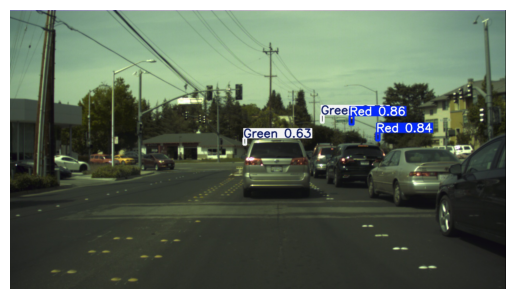

In [8]:
salvo = next(Path(results[0].save_dir).glob(f"{Path(predict_image).stem}.*"))
img = Image.open(salvo)

plt.imshow(img)
plt.axis("off")
plt.show()

In [14]:
MODEL_NANO  = "runs/detect/treino_nano/weights/best.pt"
MODEL_SMALL = "runs/detect/train-8/weights/best.pt"

TEST_IMG_DIR = Path("images/test")
TEST_LBL_DIR = Path("labels/test")
CONF_VIS     = 0.25
IOU_MATCH    = 0.5
DATA_YAML    = "data.yaml"


def carregar_gt(label_path, W, H):
    caixas = []
    if not Path(label_path).exists():
        return caixas
    for linha in open(label_path):
        linha = linha.strip()
        if not linha:
            continue
        cls, xc, yc, bw, bh = map(float, linha.split())
        x1 = (xc - bw / 2) * W;  y1 = (yc - bh / 2) * H
        x2 = (xc + bw / 2) * W;  y2 = (yc + bh / 2) * H
        caixas.append((int(cls), x1, y1, x2, y2))
    return caixas


def iou_box(a, b):
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter == 0:
        return 0.0
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)


def extrair_metricas_df(metrics, mdl, label):
    linhas = []
    for i, c in enumerate(metrics.box.ap_class_index):
        p, r, ap50, ap = metrics.box.class_result(i)
        f1 = 2*p*r/(p+r) if (p+r) > 0 else 0.0
        linhas.append({"modelo": label, "classe": mdl.names[int(c)],
                        "Precisao": round(p,4), "Recall": round(r,4),
                        "F1": round(f1,4), "mAP50": round(ap50,4), "mAP50-95": round(ap,4)})
    mp, mr = metrics.box.mp, metrics.box.mr
    linhas.append({"modelo": label, "classe": "ALL",
                   "Precisao": round(mp,4), "Recall": round(mr,4),
                   "F1": round(2*mp*mr/(mp+mr) if (mp+mr)>0 else 0, 4),
                   "mAP50": round(metrics.box.map50,4), "mAP50-95": round(metrics.box.map,4)})
    return pd.DataFrame(linhas)


def mostrar_matriz_confusao(metrics, mdl, titulo):
    save_dir = Path(metrics.save_dir)
    for nome in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
        caminho = save_dir / nome
        if caminho.exists():
            plt.figure(figsize=(8, 7))
            plt.imshow(Image.open(caminho))
            plt.axis("off")
            plt.title(f"{titulo} — {nome.replace('.png','')}")
            plt.show()
        else:
            print("Nao encontrado:", caminho)
    cm = metrics.confusion_matrix.matrix.astype(int)
    rotulos = [mdl.names[i] for i in range(len(mdl.names))] + ["background"]
    df_cm = pd.DataFrame(cm, index=rotulos, columns=rotulos)
    print(f"\nMatriz de confusao {titulo} (linhas=Predito, colunas=Verdadeiro):")
    return df_cm


def analisar_tpfpfn(mdl):
    registros = []
    for img_path in sorted(TEST_IMG_DIR.glob("*.png")):
        W, H = Image.open(img_path).size
        gts   = carregar_gt(TEST_LBL_DIR / f"{img_path.stem}.txt", W, H)
        res   = mdl.predict(img_path, conf=CONF_VIS, iou=0.6, verbose=False)[0]
        preds = [(int(b.cls[0]), *b.xyxy[0].tolist(), float(b.conf[0])) for b in res.boxes]
        gt_casados = set()
        tp = fp = erro_classe = 0
        for p in sorted(preds, key=lambda z: -z[5]):
            melhor_iou, melhor_j = 0.0, -1
            for j, g in enumerate(gts):
                if j in gt_casados:
                    continue
                v = iou_box(p[1:5], g[1:5])
                if v > melhor_iou:
                    melhor_iou, melhor_j = v, j
            if melhor_iou >= IOU_MATCH and melhor_j >= 0:
                gt_casados.add(melhor_j)
                if gts[melhor_j][0] == p[0]: tp += 1
                else: erro_classe += 1
            else:
                fp += 1
        fn    = len(gts) - len(gt_casados)
        erros = fp + fn + erro_classe
        registros.append({"img": img_path, "n_gt": len(gts), "n_pred": len(preds),
                           "tp": tp, "fp": fp, "fn": fn,
                           "erro_classe": erro_classe, "erros": erros})
    return pd.DataFrame(registros)


def mostrar_exemplos(df_reg, mdl, titulo):
    CORES = {0: "red", 1: "gold", 2: "lime"}
    names = mdl.names

    def _plot(rec):
        img_path = rec["img"]
        img = Image.open(img_path)
        W, H = img.size
        gts = carregar_gt(TEST_LBL_DIR / f"{img_path.stem}.txt", W, H)
        res = mdl.predict(img_path, conf=CONF_VIS, iou=0.6, verbose=False)[0]
        fig, ax = plt.subplots(1, 2, figsize=(16, 6))
        for a in ax:
            a.imshow(img); a.axis("off")
        ax[0].set_title("Ground Truth")
        for cls, x1, y1, x2, y2 in gts:
            ax[0].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                fill=False, edgecolor=CORES.get(cls,"white"), linewidth=2))
            ax[0].text(x1, y1-3, names[cls],
                color=CORES.get(cls,"white"), fontsize=10, weight="bold")
        ax[1].set_title(f"Predicao  |  {img_path.name}\n"
                        f"FP={rec['fp']}  FN={rec['fn']}  erro_classe={rec['erro_classe']}")
        for box in res.boxes:
            cls = int(box.cls[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            ax[1].add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                fill=False, edgecolor=CORES.get(cls,"white"), linewidth=2))
            ax[1].text(x1, y1-3, f"{names[cls]} {float(box.conf[0]):.2f}",
                color=CORES.get(cls,"white"), fontsize=10, weight="bold")
        plt.tight_layout(); plt.show()

    perfeitas = df_reg[(df_reg.erros == 0) & (df_reg.n_gt > 0)]
    com_erro  = df_reg[df_reg.erros > 0]
    print(f"\n{'='*60}\n{titulo} — EXEMPLOS BEM SUCEDIDOS\n{'='*60}")
    for _, r in perfeitas.sort_values("n_gt", ascending=False).head(3).iterrows():
        _plot(r)
    print(f"\n{'='*60}\n{titulo} — EXEMPLOS MAL SUCEDIDOS\n{'='*60}")
    for _, r in com_erro.sort_values("erros", ascending=False).head(3).iterrows():
        _plot(r)

Ultralytics 8.4.62  Python-3.13.0 torch-2.12.0+cpu CPU (Intel Core Ultra 7 155H)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1266.8247.2 MB/s, size: 1168.6 KB)
val: Scanning C:\Users\agrda\OneDrive\Área de Trabalho\yolo-bosch-traffic-lights\labels\test.cache... 300 images, 124 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 89.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.2s/it 22.1s1.2ss
                   all        300        569       0.55      0.327      0.375      0.184
                   Red        100        213      0.659      0.432      0.487      0.227
                Yellow         23         33      0.245     0.0303     0.0653      0.035
                 Green        121        323      0.747       0.52      0.572       0.29
Speed: 0.6ms preprocess, 40.0ms inference, 0.0ms loss, 0.1ms postprocess per imag

,modelo,classe,Precisao,Recall,F1,mAP50,mAP50-95
0,Nano,Red,0.6587,0.4319,0.5217,0.4869,0.2267
1,Nano,Yellow,0.2445,0.0303,0.0539,0.0653,0.0350
2,Nano,Green,0.7472,0.5201,0.6133,0.5722,0.2901
3,Nano,ALL,0.5501,0.3275,0.4105,0.3748,0.1839


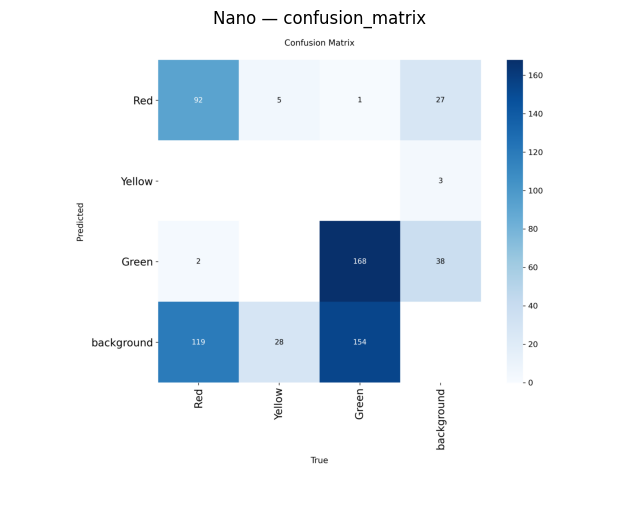

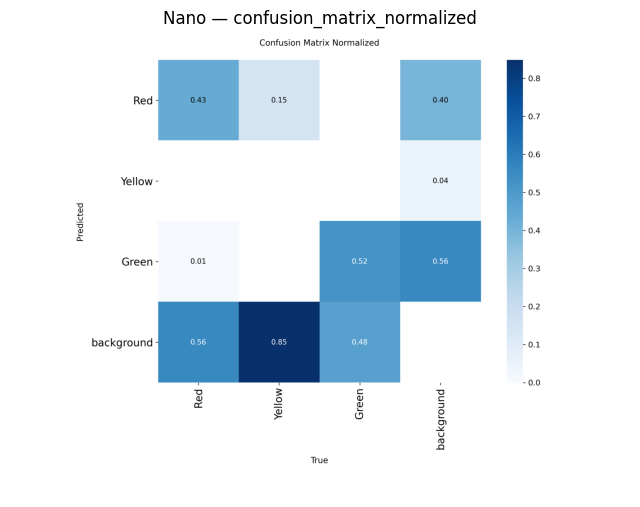


Matriz de confusao Nano (linhas=Predito, colunas=Verdadeiro):


,Red,Yellow,Green,background
Red,92,5,1,27
Yellow,0,0,0,3
Green,2,0,168,38
background,119,28,154,0



[Nano] Total: 300 | Perfeitas: 23 | Com erro: 156
[Nano] TP: 253 | FP: 76 | FN: 311 | erro_classe: 5


,img,n_gt,n_pred,tp,fp,fn,erro_classe,erros
0,images\test\100436.png,0,0,0,0,0,0,0
1,images\test\100574.png,1,0,0,0,1,0,1
2,images\test\101060.png,3,1,1,0,2,0,2
3,images\test\101130.png,3,4,3,1,0,0,1
4,images\test\101200.png,3,4,3,1,0,0,1



NANO — EXEMPLOS BEM SUCEDIDOS


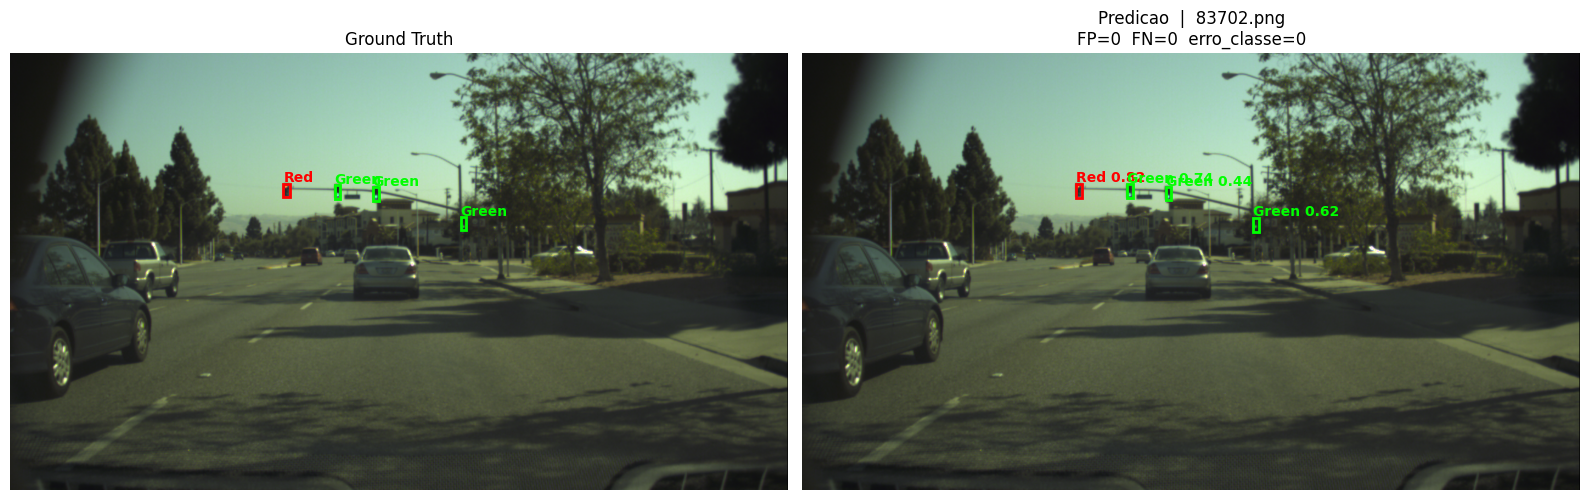

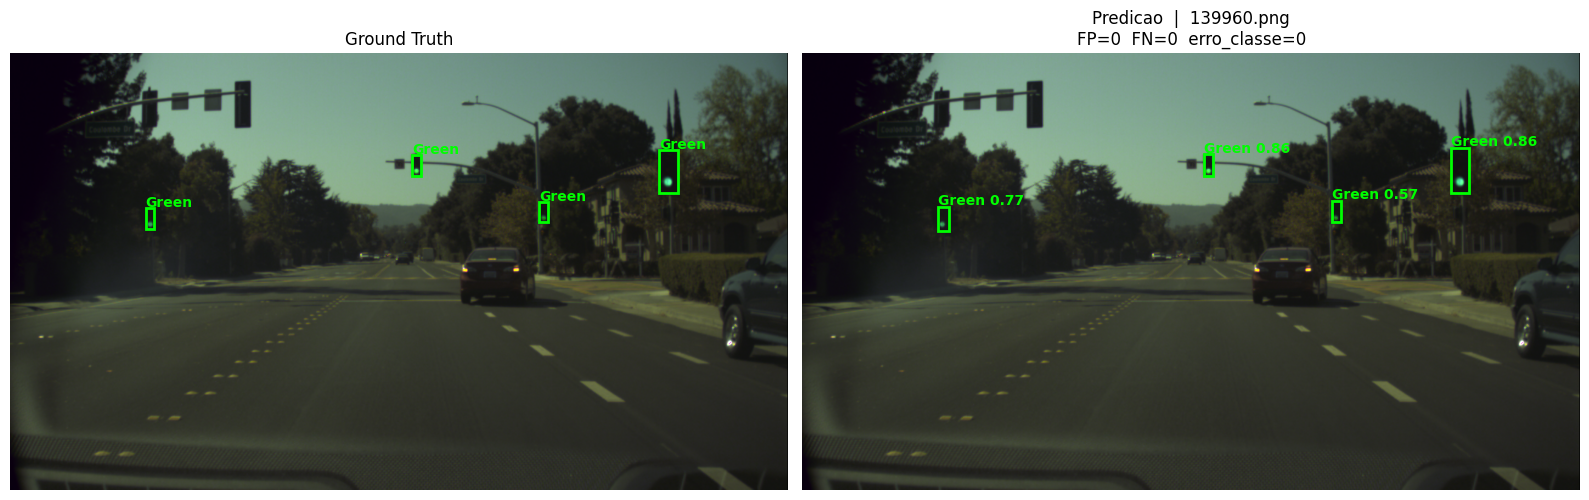

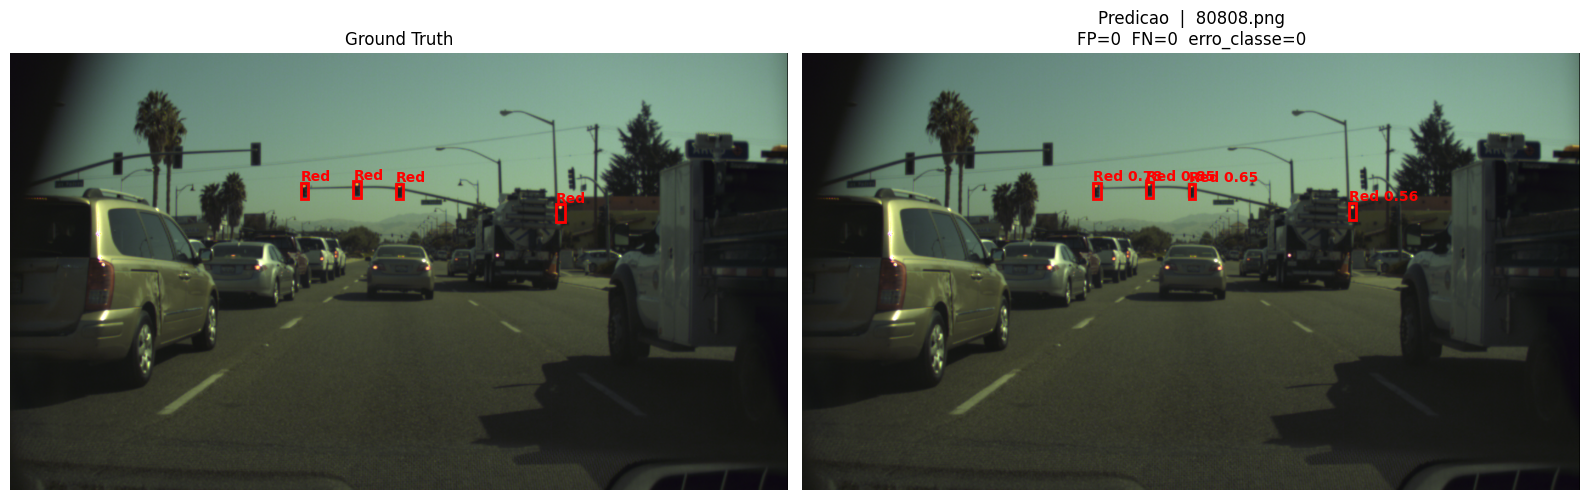


NANO — EXEMPLOS MAL SUCEDIDOS


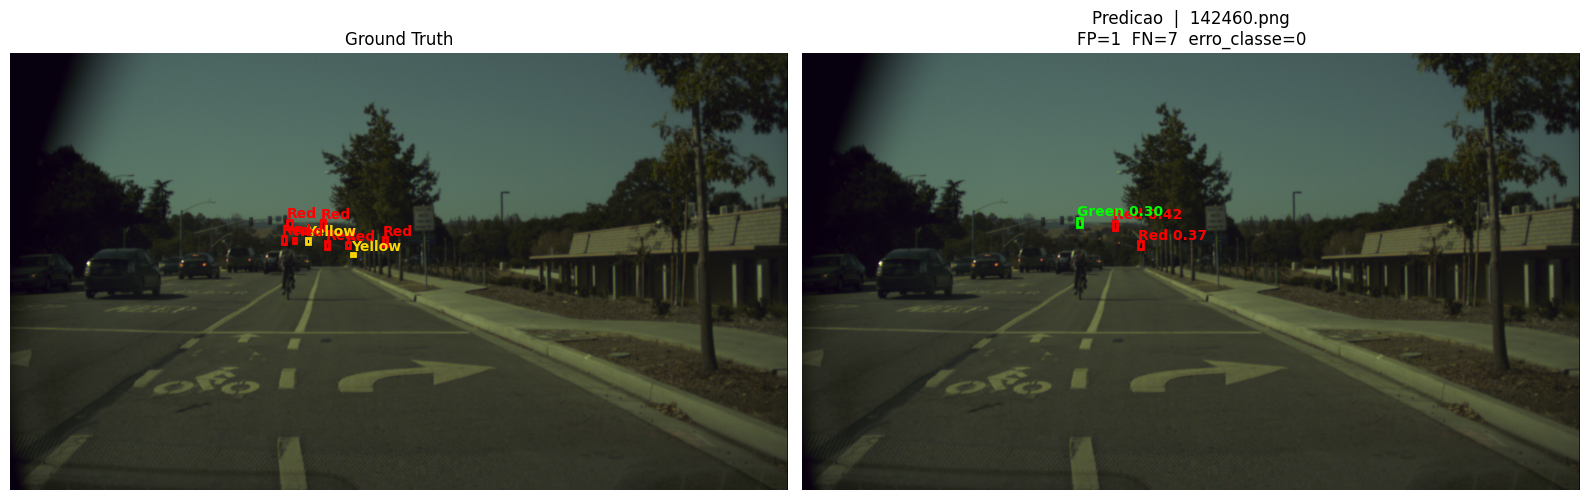

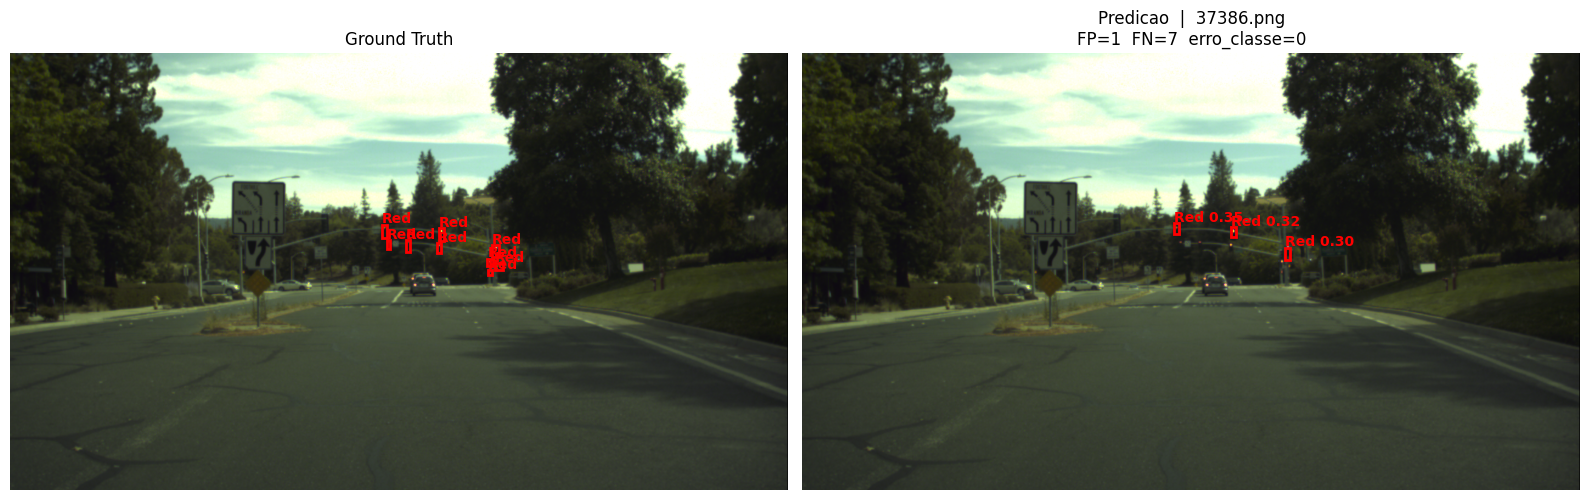

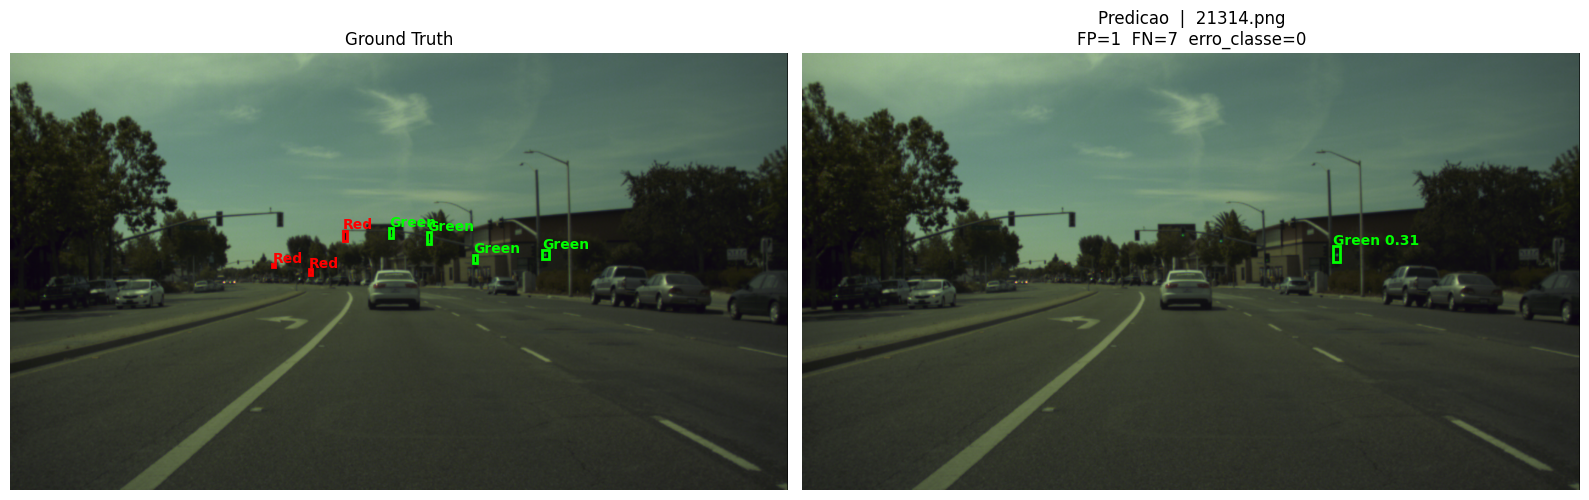

In [15]:
model_n   = YOLO(MODEL_NANO)
metrics_n = model_n.val(data=DATA_YAML, split="test", imgsz=640,
                         conf=0.001, iou=0.6, plots=True, verbose=True)

df_n = extrair_metricas_df(metrics_n, model_n, "Nano")
print("===== Nano — Métricas por classe =====")
display(df_n)

display(mostrar_matriz_confusao(metrics_n, model_n, "Nano"))

df_reg_n    = analisar_tpfpfn(model_n)
perfeitas_n = df_reg_n[(df_reg_n.erros == 0) & (df_reg_n.n_gt > 0)]
com_erro_n  = df_reg_n[df_reg_n.erros > 0]
print(f"\n[Nano] Total: {len(df_reg_n)} | Perfeitas: {len(perfeitas_n)} | Com erro: {len(com_erro_n)}")
print(f"[Nano] TP: {df_reg_n.tp.sum()} | FP: {df_reg_n.fp.sum()} | FN: {df_reg_n.fn.sum()} | erro_classe: {df_reg_n.erro_classe.sum()}")
display(df_reg_n.head())

mostrar_exemplos(df_reg_n, model_n, "NANO")

Ultralytics 8.4.62  Python-3.13.0 torch-2.12.0+cpu CPU (Intel Core Ultra 7 155H)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2007.081.3 MB/s, size: 1153.5 KB)
val: Scanning C:\Users\agrda\OneDrive\Área de Trabalho\yolo-bosch-traffic-lights\labels\test.cache... 300 images, 124 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 104.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.4s/it 27.3s1.8ss
                   all        300        569      0.785      0.427      0.524      0.264
                   Red        100        213      0.804      0.596      0.679      0.327
                Yellow         23         33      0.682     0.0909      0.181     0.0837
                 Green        121        323      0.869      0.595      0.714      0.382
Speed: 0.4ms preprocess, 71.7ms inference, 0.0ms loss, 0.3ms postprocess per ima

,modelo,classe,Precisao,Recall,F1,mAP50,mAP50-95
0,Small,Red,0.8037,0.5958,0.6843,0.6786,0.3271
1,Small,Yellow,0.6818,0.0909,0.1604,0.1806,0.0837
2,Small,Green,0.8689,0.5952,0.7065,0.7136,0.3818
3,Small,ALL,0.7848,0.4273,0.5533,0.5243,0.2642


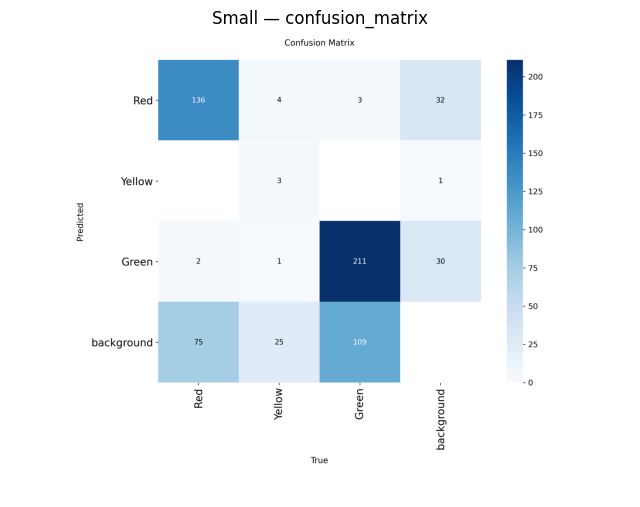

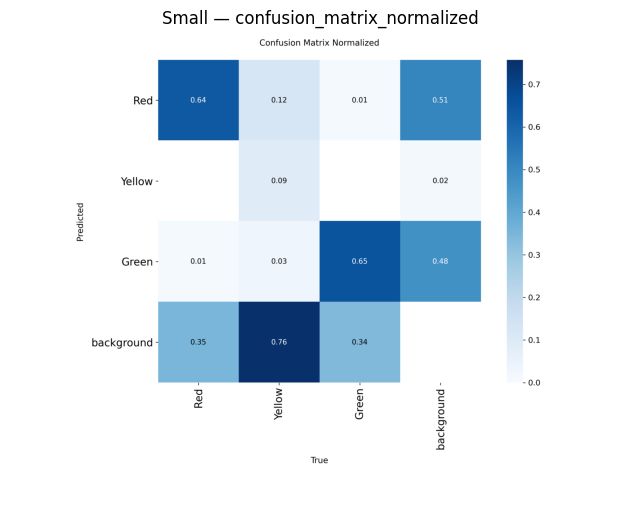


Matriz de confusao Small (linhas=Predito, colunas=Verdadeiro):


,Red,Yellow,Green,background
Red,136,4,3,32
Yellow,0,3,0,1
Green,2,1,211,30
background,75,25,109,0



[Small] Total: 300 | Perfeitas: 46 | Com erro: 133
[Small] TP: 336 | FP: 78 | FN: 224 | erro_classe: 9


,img,n_gt,n_pred,tp,fp,fn,erro_classe,erros
0,images\test\100436.png,0,0,0,0,0,0,0
1,images\test\100574.png,1,0,0,0,1,0,1
2,images\test\101060.png,3,3,3,0,0,0,0
3,images\test\101130.png,3,4,3,1,0,0,1
4,images\test\101200.png,3,3,3,0,0,0,0



SMALL — EXEMPLOS BEM SUCEDIDOS


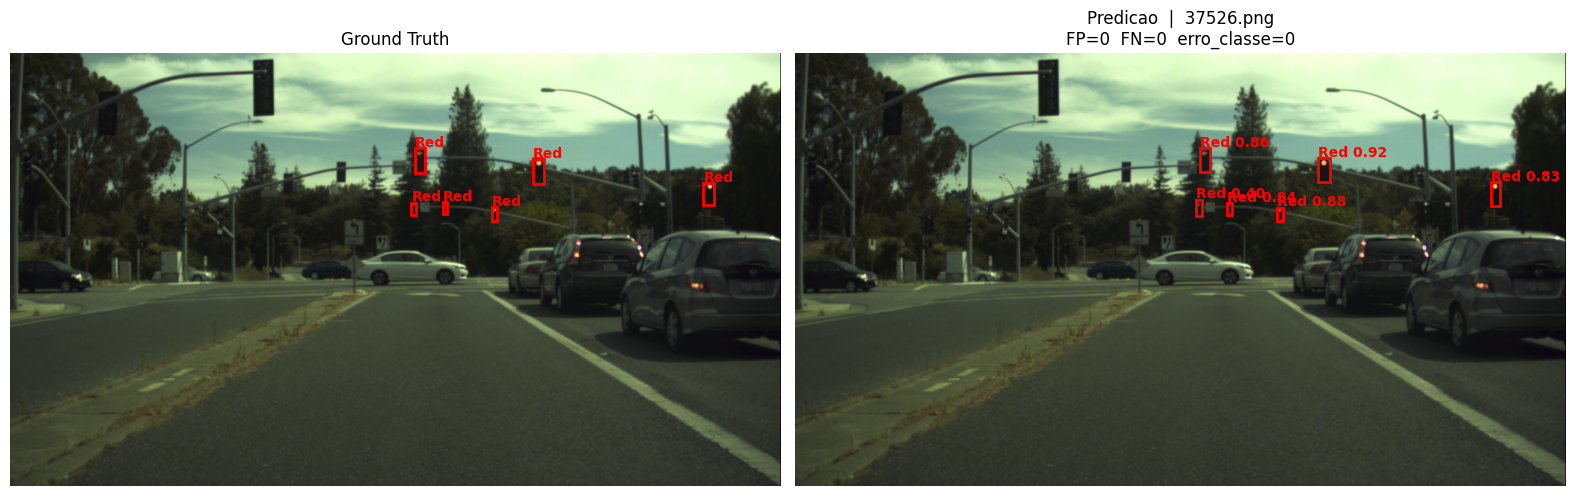

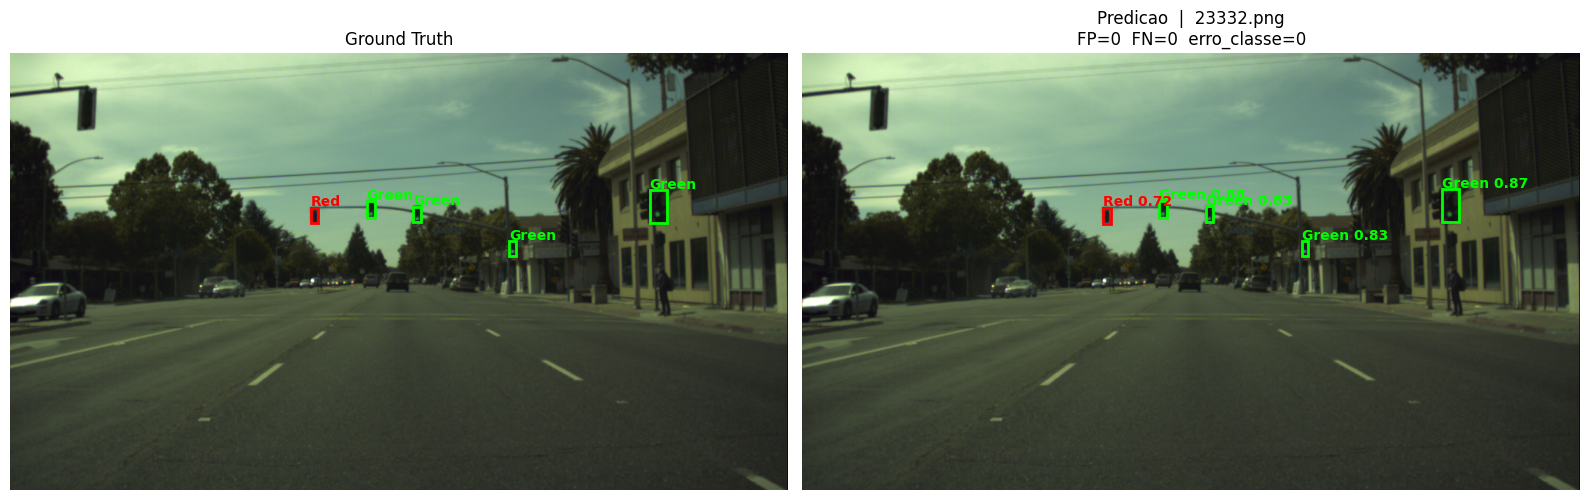

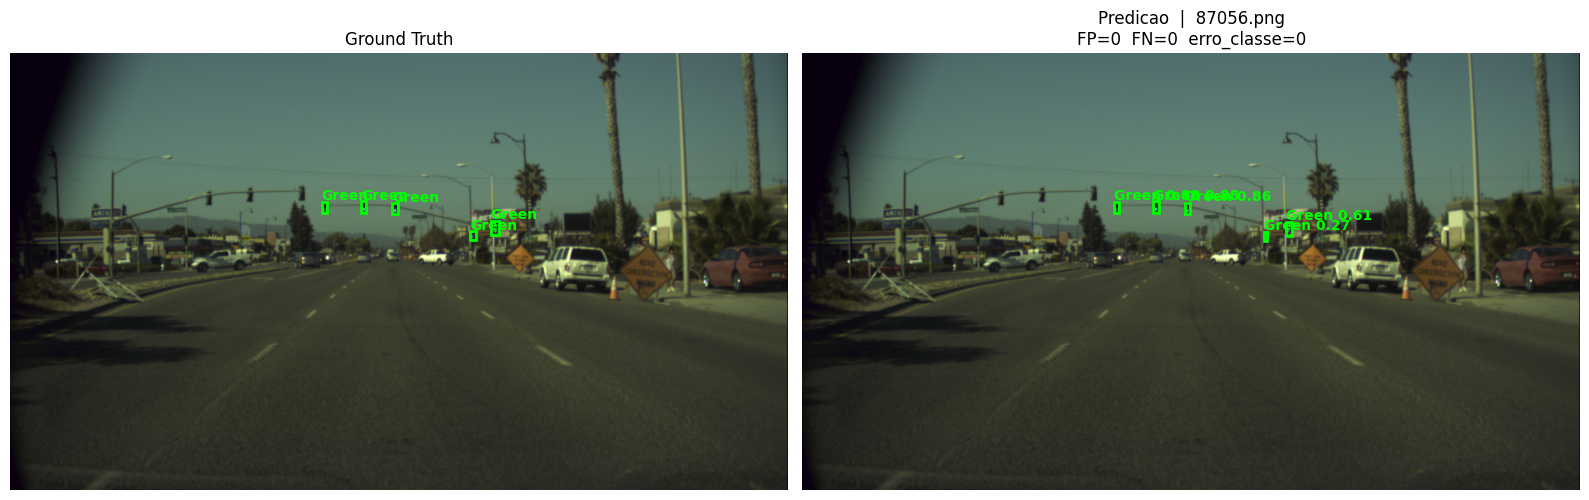


SMALL — EXEMPLOS MAL SUCEDIDOS


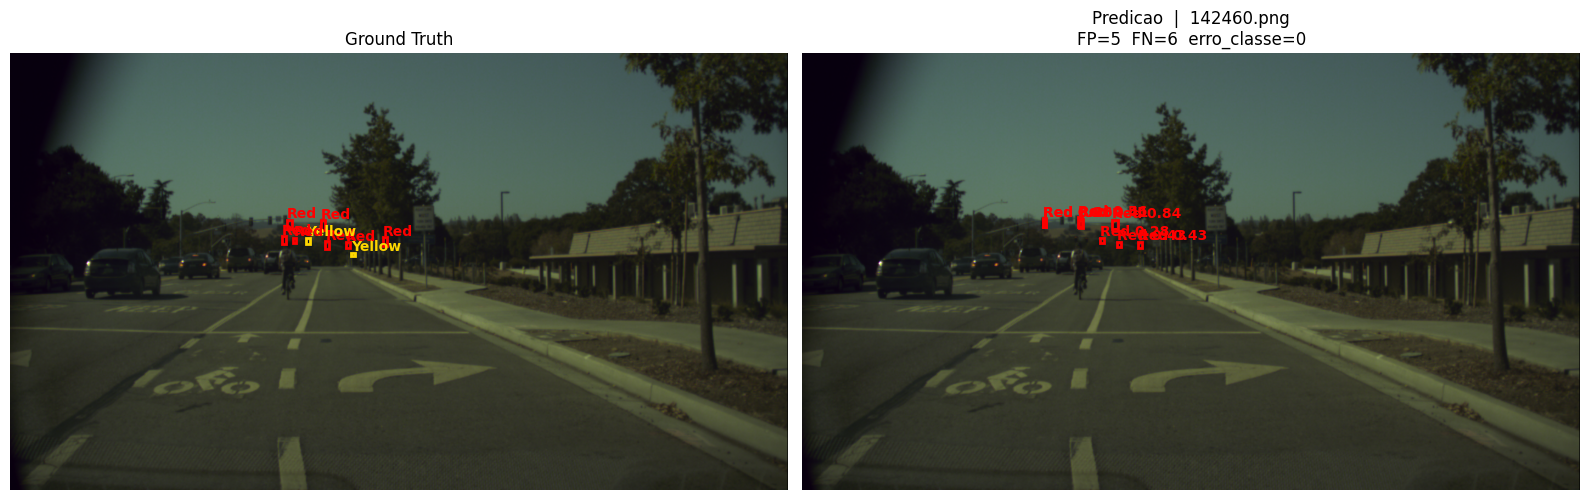

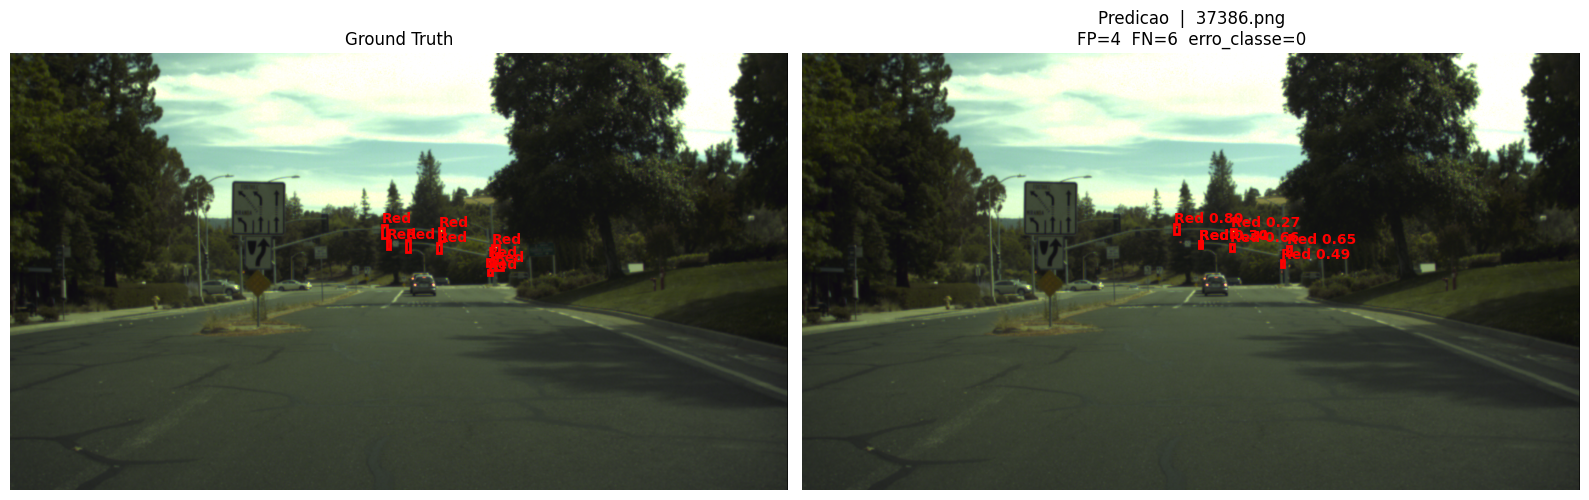

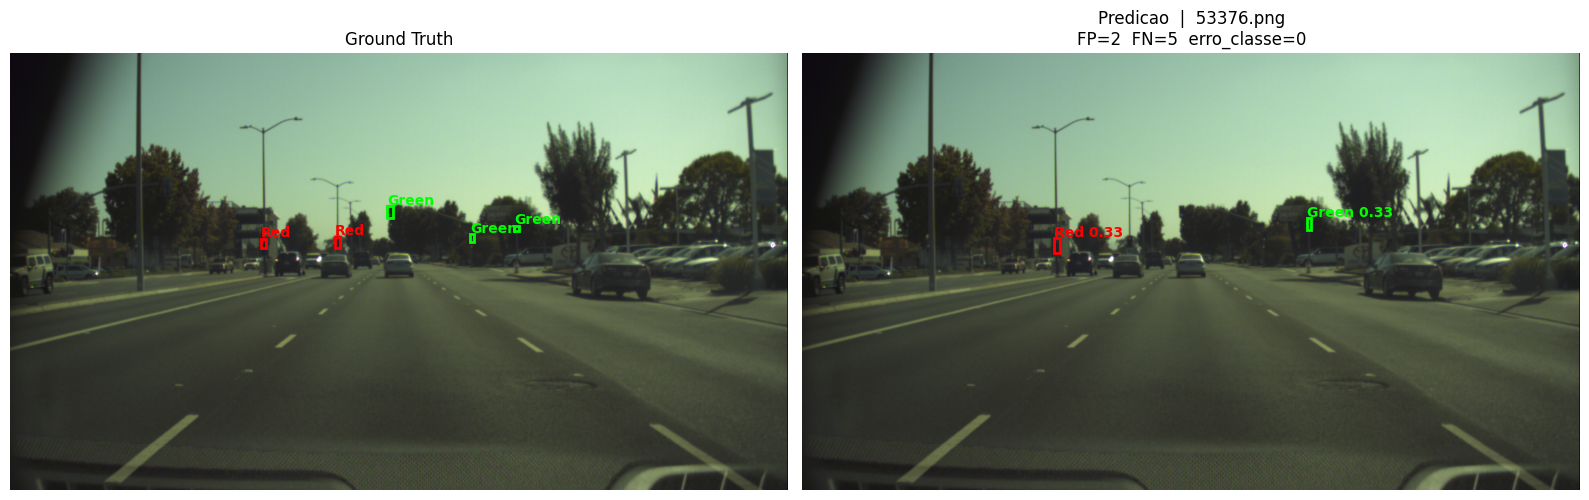

In [16]:
model_s   = YOLO(MODEL_SMALL)
metrics_s = model_s.val(data=DATA_YAML, split="test", imgsz=640,
                         conf=0.001, iou=0.6, plots=True, verbose=True)

df_s = extrair_metricas_df(metrics_s, model_s, "Small")
print("===== Small — Métricas por classe =====")
display(df_s)

display(mostrar_matriz_confusao(metrics_s, model_s, "Small"))

df_reg_s    = analisar_tpfpfn(model_s)
perfeitas_s = df_reg_s[(df_reg_s.erros == 0) & (df_reg_s.n_gt > 0)]
com_erro_s  = df_reg_s[df_reg_s.erros > 0]
print(f"\n[Small] Total: {len(df_reg_s)} | Perfeitas: {len(perfeitas_s)} | Com erro: {len(com_erro_s)}")
print(f"[Small] TP: {df_reg_s.tp.sum()} | FP: {df_reg_s.fp.sum()} | FN: {df_reg_s.fn.sum()} | erro_classe: {df_reg_s.erro_classe.sum()}")
display(df_reg_s.head())

mostrar_exemplos(df_reg_s, model_s, "SMALL")

In [12]:
df_comp = (pd.concat([df_n, df_s])
             .set_index(["classe", "modelo"])
             .sort_index())
print("===== Comparativo mAP/Precisao/Recall — Nano vs Small =====")
display(df_comp)

resumo_tpfp = pd.DataFrame([
    {"modelo": "Nano",  "Imagens perfeitas": len(perfeitas_n), "Com erro": len(com_erro_n),
     "TP": int(df_reg_n.tp.sum()), "FP": int(df_reg_n.fp.sum()),
     "FN": int(df_reg_n.fn.sum()), "Erro classe": int(df_reg_n.erro_classe.sum())},
    {"modelo": "Small", "Imagens perfeitas": len(perfeitas_s), "Com erro": len(com_erro_s),
     "TP": int(df_reg_s.tp.sum()), "FP": int(df_reg_s.fp.sum()),
     "FN": int(df_reg_s.fn.sum()), "Erro classe": int(df_reg_s.erro_classe.sum())},
]).set_index("modelo")
print(f"\n===== Comparativo TP/FP/FN (conf={CONF_VIS}) =====")
display(resumo_tpfp)

===== Comparativo mAP/Precisao/Recall — Nano vs Small =====


Precisao  Recall      F1   mAP50  mAP50-95
classe modelo                                            
ALL    Nano      0.5501  0.3275  0.4105  0.3748    0.1839
       Small     0.7848  0.4273  0.5533  0.5243    0.2642
Green  Nano      0.7472  0.5201  0.6133  0.5722    0.2901
       Small     0.8689  0.5952  0.7065  0.7136    0.3818
Red    Nano      0.6587  0.4319  0.5217  0.4869    0.2267
       Small     0.8037  0.5958  0.6843  0.6786    0.3271
Yellow Nano      0.2445  0.0303  0.0539  0.0653    0.0350
       Small     0.6818  0.0909  0.1604  0.1806    0.0837


===== Comparativo TP/FP/FN (conf=0.25) =====


,Imagens perfeitas,Com erro,TP,FP,FN,Erro classe
modelo,,,,,,
Nano,23,156,253,76,311,5
Small,46,133,336,78,224,9
